In [36]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [37]:
class user_validate(TypedDict):
    user : str
    password : str
    message : str
    status : str

In [38]:
user_credentials = {
    "alice": "alice123",
    "bob": "bob@2025",
    "charlie": "charlie_pass",
    "diana": "Diana!456",
    "eve": "eve_secure"
}

In [39]:
def check_username(state: user_validate):
    username = state.get("user_credential")
    if username and username in user_credentials:
        return {"status": "user_found"}
    else:
        return {"status": "user_not_found"}


In [40]:
def check_password(state: user_validate):
    username = state["user_credential"]
    password = state["password"]

    if user_credentials.get(username) == password:
        return {"auth_status": "correct"}
    else:
        return {"auth_status": "incorrect"}


In [41]:
def login_success(state: user_validate):
    return {"auth_status": "login_successful"}


In [42]:
def login_failed(state: user_validate):
    return {"auth_status": "login_failed"}


In [43]:
def username_condition(state: user_validate) -> Literal["found", "not_found"]:
    return "found" if state["status"] == "user_found" else "not_found"


In [44]:
def password_condition(state: user_validate) -> Literal["correct", "incorrect"]:
    return state["auth_status"]


In [45]:

graph = StateGraph(user_validate)
graph.add_node("check_username", check_username)
graph.add_node("check_password", check_password)
graph.add_node("login_success", login_success)
graph.add_node("login_failed", login_failed)

graph.add_edge(START, "check_username")
graph.add_conditional_edges(
    "check_username",
    username_condition,
    {
        "found": "check_password",
        "not_found": "login_failed"
    }
)

graph.add_conditional_edges(
    "check_password",
    password_condition,
    {
        "correct": "login_success",
        "incorrect": "login_failed"
    }
)

graph.add_edge("login_success", END)
graph.add_edge("login_failed", END)

workflow = graph.compile()


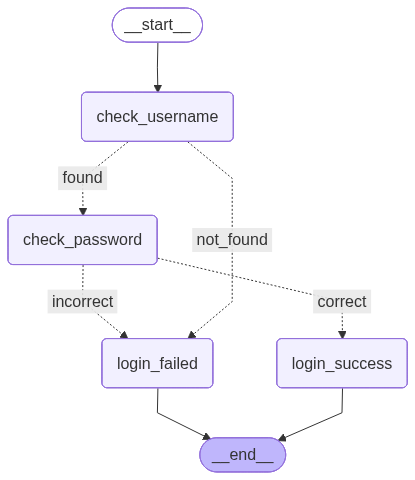

In [46]:
workflow

In [47]:
initial_state = {
    'user_credential': "alice",
    'password': "alice123",
    'status': ""
}

workflow.invoke(initial_state)


{'password': 'alice123', 'status': 'user_not_found'}